In [8]:
from typing import Annotated
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI


from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [9]:
from langchain.chat_models import init_chat_model



In [10]:
llm = ChatOpenAI(
    model="gpt-4o-mini",   # or "gpt-4o" depending on your plan
    temperature=0,
)


class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State) -> State:
    return {"messages": [llm.invoke(state["messages"])]}


In [11]:

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)

builder.add_edge(START, "chatbot_node")
builder.add_edge("chatbot_node", END)

graph = builder.compile()

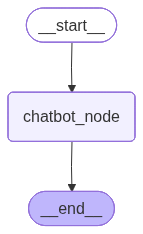

In [12]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
message = {"role": "user", "content": "Who walked on the moon for the first time? Print only the name"}
# message = {"role": "user", "content": "What is the latest price of MSFT stock?"}
response = graph.invoke({"messages":[message]})

response["messages"]

[HumanMessage(content='Who walked on the moon for the first time? Print only the name', additional_kwargs={}, response_metadata={}, id='0fae584a-2320-480e-9391-345790c7ca50'),
 AIMessage(content='Neil Armstrong', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 2, 'prompt_tokens': 21, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CMQMAeRIOot95lLju5xcAdi0HRLp8', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c3c5a891-24d2-4b5a-b860-996cdfc669bb-0', usage_metadata={'input_tokens': 21, 'output_tokens': 2, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

In [22]:
response["messages"][1].content

'Neil Armstrong'

In [ ]:
state = 2
while True:
    in_message = input("You: ")
    if in_message.lower() in {"quit","exit"}:
        break
    if state is None:
        state: State = {
            "messages": [{"role": "user", "content": in_message}]
        }
    else:
        state["messages"].append({"role": "user", "content": in_message})

    state = graph.invoke(state)
    print("Bot:", state["messages"][-1].content)

Bot: Sure! Here are 20 sentences about Pakistan:

1. Pakistan is located in South Asia and shares borders with India, Afghanistan, Iran, and China.
2. The country was established on August 14, 1947, following the partition of British India.
3. Islamabad is the capital city of Pakistan, while Karachi is its largest city and economic hub.
4. The official language of Pakistan is Urdu, but English is also widely used in government and business.
5. Pakistan has a diverse landscape that includes mountains, deserts, and coastal areas.
6. The country is home to some of the world's highest peaks, including K2, the second-highest mountain.
7. The Indus River, one of the longest rivers in the world, flows through Pakistan and is vital for agriculture.
8. Pakistan has a rich cultural heritage, influenced by various civilizations, including the Indus Valley Civilization.
9. The country is known for its vibrant music, dance, and art, with traditional forms like Qawwali and Bhangra.
10. Pakistan's cu